# 🧱 LLM System Building

In this section, we'll learn how to **build production-ready systems** using LLMs,  
RAG pipelines, and agent-based orchestration.

You'll explore how to:
- Build RAG pipelines 🧰
- Implement tool/function calling 🛠️
- Work with Agents (ReAct, AutoGPT, CrewAI)
- Handle fallbacks & retries
- Use orchestration frameworks: **LangChain**, **LlamaIndex**, **Haystack**, **LangGraph**


## 1. RAG Pipeline Orchestration 🔗

A RAG (Retrieval-Augmented Generation) pipeline has:
1. **Document ingestion** → chunking & embeddings
2. **Retrieval** → from vector DB (Chroma, FAISS, Qdrant, Weaviate)
3. **Context injection** → into prompt template
4. **Generation** → answer with retrieved context

We use `LangChain` to connect these components seamlessly.

### https://www.langchain.com

---
---

## 2. Tool/Function Calling 🛠️

- LLMs can **call external tools** (e.g., calculators, APIs, search engines).  
- LangChain provides `tools` and `functions` that agents can invoke when needed.  
- This allows LLMs to **act beyond text**: search the web, run code, fetch weather, etc.


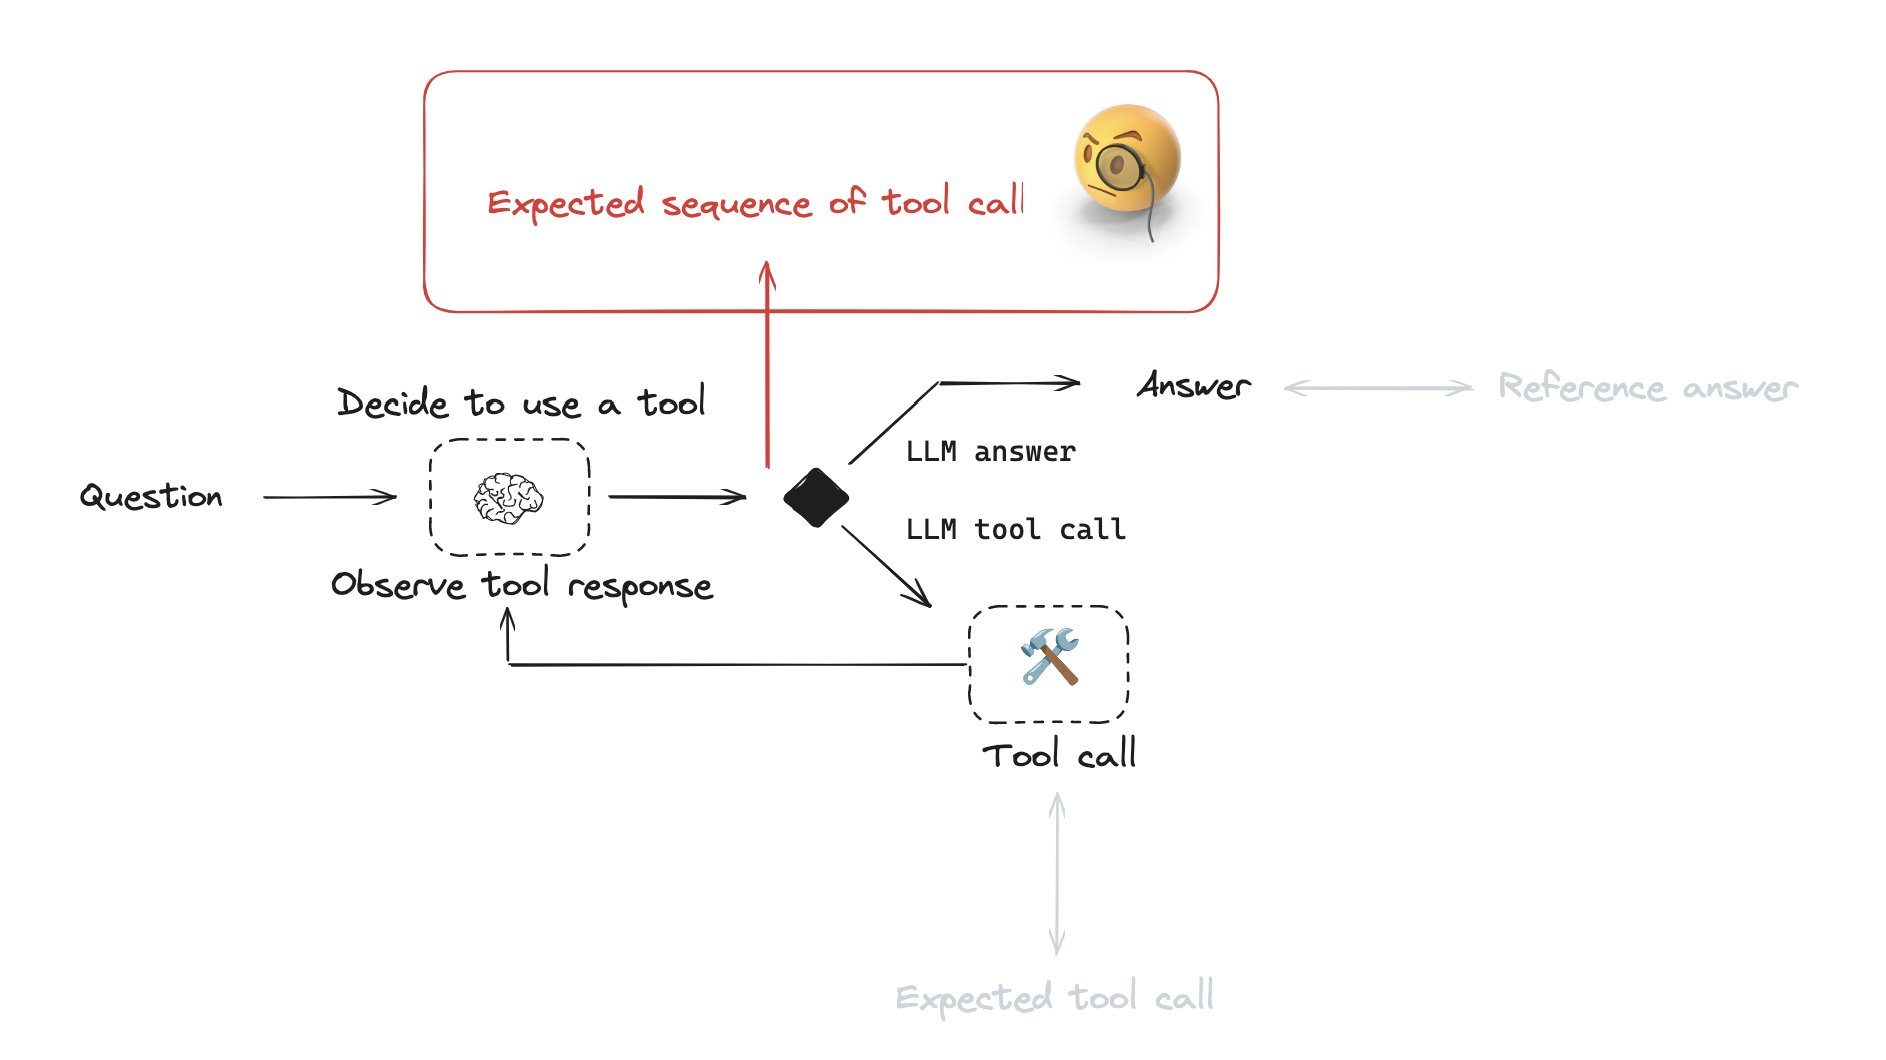

In [7]:
from IPython.display import Image

Image(filename='data/tools.jpeg')


In [4]:
from langchain.agents import initialize_agent, Tool
from langchain.chat_models import ChatOpenAI
from os import getenv
from dotenv import load_dotenv

load_dotenv(dotenv_path='./data/.env') 

llm = ChatOpenAI(
openai_api_base=getenv("OPENROUTER_BASE_URL"),
openai_api_key=getenv("OPENROUTER_API_KEY"),
model_name="google/gemma-3-27b-it:free",
)

def add_numbers(a: int, b: int) -> int:
    return a + b


tools = [
    Tool(
        name="Addition Tool",
        func=lambda x: add_numbers(*map(int, x.split(","))),
        description="Adds two numbers, input as: 'a,b'"
    )
]

agent = initialize_agent(tools, llm, agent="zero-shot-react-description", verbose=True)
agent.run("Add 12 and 30")




> Entering new AgentExecutor chain...


/Users/kaps/Developer/thinkOpenAi/.venv/lib/python3.11/site-packages/langchain_community/chat_models/openai.py:495: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  response = response.dict()


Thought: The question asks me to add two numbers, 12 and 30. I should use the Addition Tool to do this.
Action: Addition Tool
Action Input: 12,30
Observation: 42
Thought:I now know the final answer.
Final Answer: 42

> Finished chain.


/Users/kaps/Developer/thinkOpenAi/.venv/lib/python3.11/site-packages/langchain_community/chat_models/openai.py:495: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  response = response.dict()


'42'

In [6]:
from langchain.tools import DuckDuckGoSearchRun
from langchain.agents import initialize_agent, AgentType

search = DuckDuckGoSearchRun()

def multiply_numbers(a: str, b: str) -> str:
    return str(float(a) * float(b))

tools = [
    Tool(
        name="DuckDuckGo Search",
        func=search.run,
        description="Useful for when you need to look something up on the internet"
    ),
    Tool(
        name="Multiplier",
        func=lambda x: multiply_numbers(*x.split()),
        description="Multiplies two numbers. Input format: '3 4'"
    )
]

agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
)


response = agent.run("what is capital of india")
response




> Entering new AgentExecutor chain...


/Users/kaps/Developer/thinkOpenAi/.venv/lib/python3.11/site-packages/langchain_community/chat_models/openai.py:495: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  response = response.dict()
/Users/kaps/Developer/thinkOpenAi/.venv/lib/python3.11/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:



Thought: I need to find out the capital of India. I will use a search engine for this.
Action: DuckDuckGo Search
Action Input: "capital of india"
Observation: Aug 1, 2025 · Check the complete list of Indian States and Capitals with their formation dates, cultures, and key facts. Learn their significance and uniqueness in India's rich heritage. 2 days ago · India, a country of immense diversity and vibrant culture, is divided into states and union territories, each with its own capital. Understanding the List of Indian states and capitals … Jan 10, 2025 · Delhi became the capital of India on February 13, 1931. Before this, Kolkata was the capital of British India. The decision to move the capital from Kolkata to Delhi was … 4 days ago · The National Capital, New Delhi, is situated within the National Capital Territory of Delhi. Telangana is the most recently formed State of India which was created on June 2, … 4 days ago · States and Capitals of India 2025: Check list of 28 States in A

/Users/kaps/Developer/thinkOpenAi/.venv/lib/python3.11/site-packages/langchain_community/chat_models/openai.py:495: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  response = response.dict()


'New Delhi'

---
---

### langchain Tools : https://python.langchain.com/docs/integrations/tools/
### Demo SQL agent : https://github.com/Kaps-programer-9123/thinkOpenAi/blob/main/gen_ai_notebook/notebooks/agens_tools/sql_agent.ipynb

---
---

In [ ]:
import openai
import requests

openai.api_key = "your-openai-api-key"

def get_news():
    # Example of fetching news from a news API like NewsAPI
    api_key = "your-news-api-key"
    base_url = "https://newsapi.org/v2/top-headlines"
    params = {
        'country': 'us',
        'apiKey': api_key
    }
    response = requests.get(base_url, params=params)
    news_data = response.json()
    
    if news_data.get("articles"):
        top_article = news_data["articles"][0]
        return f"Top headline: {top_article['title']} - {top_article['description']}"
    else:
        return "Sorry, I couldn't fetch the news right now."

# Chatbot calls the news fetching function
def chatbot(query):
    if "news" in query.lower():
        return get_news()
    else:
        return "I can only provide the latest news right now."

# Example usage
query = "What's the latest news?"
response = chatbot(query)
print(response)
